# Neural Flows

The diea is to train a neural flow model that transforms the distribution of our morphological parameters $p(x)$ into a Gaussian distribution $p(z)$. Then the latent space of that model should learn something about the dataset.

We do this conditionally on a few parameters:
* Brightness: r-magnitude
* Nuisance parameters: SNR, PSF FWHM
This way the question is, given this r-band magnitude and these nuisance parameters, what is the probability that a galaxy should have this set of morphological measurements?

Irregular galaxies will then be flagged as artifacts (e.g., different ellipticity metrics don't match; asymmetry is high; etc.)

---

#### Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
import h5py
from sklearn.preprocessing import RobustScaler
from sklearn.preprocessing import QuantileTransformer
%matplotlib inline

### Load the data

The data is stored as an HDF5 file with the following datasets:
* `meta`: tile names, galaxy ID from the source catalog, ra, dec, PSF FWHM
* `morph`: morphological measurements
* `diag`: diagnostic columns (flag, Sersic flag, background RMS, etc)

In [2]:
morph_file = h5py.File('../catalogs/unions_morphology.h5', 'r')

In [3]:
n_galaxies = morph_file.attrs['n_galaxies']

We want to be able to load two arrays: conditioninig variables and training variables.

* Conditioning: magnitude, SNR, PSF FWHM
* Training: morphology metrics

In [4]:
conditioning = ['meta/mag_ellip','meta/fwhm','diag/sky_median','diag/sky_sigma','diag/sn_per_pixel']
training = [f'morph/{p}' for p in list(morph_file['morph'].keys())] + ['diag/nx_stamp','diag/ny_stamp','diag/sersic_chi2_dof']
training = [p for p in training if p not in ['morph/flux_ellip', 'morph/sersic_amplitude']]

Read the whole dataset into memory:

In [5]:
print(morph_file['diag'].keys())

<KeysViewHDF5 ['flag', 'flag_sersic', 'nx_stamp', 'ny_stamp', 'sersic_aic', 'sersic_bic', 'sersic_chi2_dof', 'sky_mean', 'sky_median', 'sky_sigma', 'sn_per_pixel', 'xmax_stamp', 'xmin_stamp', 'ymax_stamp', 'ymin_stamp']>


Exclude galaxies with poor firs (-99) in all columns:

In [11]:
failed_fits = (
    (morph_file['diag/flag'][:] == 4) | 
    (np.isnan(morph_file['meta/mag_ellip'][:])) |
    (morph_file['meta/mag_ellip'][:] > 30)
)

Create a new file to write our pre-processed dataset:

In [636]:
dset_file = h5py.File('../catalogs/dataset.h5', 'a')

In [7]:
dset_file['meta/idx'] = morph_file['meta/idx'][~failed_fits]
dset_file['meta/tile'] = morph_file['meta/tile'][~failed_fits]
dset_file['meta/xc'] = morph_file['meta/xc_centroid'][~failed_fits]
dset_file['meta/yc'] = morph_file['meta/yc_centroid'][~failed_fits]
dset_file['meta/ra'] = morph_file['meta/ra'][~failed_fits]
dset_file['meta/dec'] = morph_file['meta/dec'][~failed_fits]

Add r-band magnitude:

## Anomalous values

To help the flow, we should 

* Flag columns with anomalous values (e.g., -999 or NaN or impossible ones) 
* Replace them with the dataset median, but store the flag column for now

For each parameter, print its min, max, and look at the histogram to see which values are anomalous.

In [633]:
len(training)

51

meta/fwhm
Min: 0.490
Max: 1.000
Quantiles: [0.6  0.86]


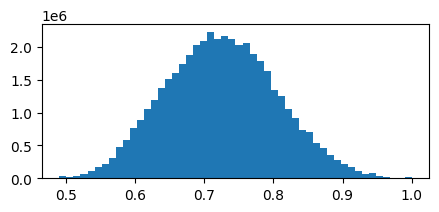

In [649]:
i = 1
param = conditioning[i]
paramname = param.split('/')[1]
print(param)

arr = morph_file[param][(~failed_fits)]
print(f'Min: {np.min(arr):0.3f}')
print(f'Max: {np.max(arr):0.3f}')
print(f'Quantiles:', np.nanquantile(arr, q=[0.05,0.95]))

plt.figure(figsize=(5,2))
plt.hist(arr, bins=50);

meta/fwhm
Min: 0.490
Max: 1.000
Quantiles: [0.6  0.86]


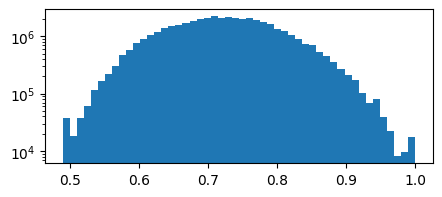

In [650]:
param_mask = np.isnan(arr) #| (arr > 1000)# | (arr  < 1)
# param_mask = (arr==1) | (arr==1/22 | (arr==1/3)

arr_clean = arr[~param_mask]
print(param)

print(f'Min: {np.min(arr_clean):0.3f}')
print(f'Max: {np.max(arr_clean):0.3f}')
print(f'Quantiles:', np.nanquantile(arr_clean, q=[0.05,0.95]))

plt.figure(figsize=(5,2))
plt.hist(arr_clean, bins=50);
plt.yscale('log')

Look at masked galaxies in the UNIONS cutout service:

In [651]:
ids = np.sort(np.random.choice(np.arange(len(arr))[param_mask], size=20, replace=False))
ras = dset_file['meta/ra'][ids]
decs = dset_file['meta/dec'][ids]
for ra, dec in zip(ras, decs):
    print(f'{ra:0.5f} {dec:0.5f}')

ValueError: 'a' cannot be empty unless no samples are taken

Fill in the masked values with random values:



In [652]:
std = (np.quantile(arr_clean, q=0.84)-np.quantile(arr_clean, q=0.16))/2
median = np.median(arr_clean)
print(std, median)
fill_values = np.random.normal(loc=median, scale=0.5*std, size=np.sum(param_mask))
fill_values[fill_values <= 1] = np.random.normal(loc=median+std, scale=0.1*std, size=np.sum(fill_values<=1))
# fill_values[fill_values <= 0] = 1e-3
# fill_values[fill_values >= 1] = 1e-3
arr[param_mask] = fill_values

0.08000000000000002 0.72


In [653]:
np.min(arr)

0.49

In [654]:
np.sum(param_mask)/len(arr)

0.0

Transform the data with a well-defined function to make it more linearly distributed:

In [655]:
# scaler = QuantileTransformer(output_distribution='normal')
# arr_transformed = scaler.fit_transform(arr.reshape(-1, 1))[:,0]

Min: -0.310
Max: 0.000
Quantiles: [-0.22184875 -0.06550155]


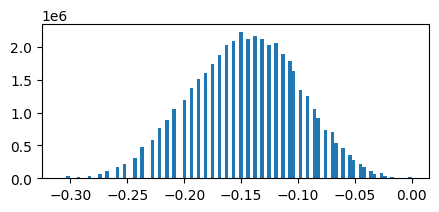

In [656]:
# arr_transformed = np.sqrt(arr)
arr_transformed = np.log10(arr)
# arr_transformed = np.arcsinh(arr)
# arr_transformed = arr

print(f'Min: {np.min(arr_transformed):0.3f}')
print(f'Max: {np.max(arr_transformed):0.3f}')
print(f'Quantiles:', np.nanquantile(arr_transformed, q=[0.05,0.95]))

plt.figure(figsize=(5,2))
plt.hist(arr_transformed, bins=100);
# plt.yscale('log')

Normalize the data using RobustScaler:

In [657]:
# scaler = RobustScaler(quantile_range=(0.16,0.84))
# arr_new = scaler.fit_transform(arr_transformed.reshape(-1, 1))[:,0]
arr_new = arr_transformed

Min: -0.310
Max: 0.000
Quantiles: [-0.22184875 -0.06550155]


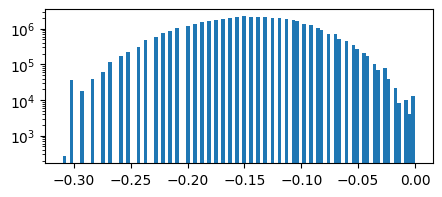

In [658]:
print(f'Min: {np.min(arr_new):0.3f}')
print(f'Max: {np.max(arr_new):0.3f}')
print(f'Quantiles:', np.nanquantile(arr_new, q=[0.05,0.95]))

plt.figure(figsize=(5,2))
plt.hist(arr_new, bins=100);
plt.yscale('log')

In [659]:
# Fill in the masked values with random Gaussian ones
# mean, std = np.median(arr_new), np.std(arr_new)
# arr_new[param_mask] = np.random.normal(mean, std, size=np.sum(param_mask))

Save the new array into our dataset file:

In [660]:
try:
    del dset_file[f'masks/mask_{paramname}']
    del dset_file[f'condition/{paramname}']
except:
    pass
# dset_file[f'masks/mask_{paramname}'] = param_mask
dset_file[f'condition/{paramname}'] = arr_new

In [661]:
dset_file.keys()

<KeysViewHDF5 ['condition', 'masks', 'meta', 'training']>

## Record of transformations

* Up to deviation - wasn't keeping up tabs
* Concentration: cut at $C<6$; no transform
* Deviation: cut at (-10, 5); $\log x+10^{-2}$
* Ellipticity: nothing
* Elongation: cutout at $e < 20$; $\log x$
* Gini: $G>0$, no transform
* Gini-M20 bulge: (-2,2)
* Gini-M20 merger: >-0.5
* Intensity: >0, <1
* M20: (-2.5, 1)
* Multimode: remove 1, 1/2, 1/3 values
* Orientation: nothing
* Outer asymmetry: (-1, 2); arcinh(x)
* R20: <100; log(x). **Note: the masked values are all cirrus which is pretty cool**
* R50: <200; log(x). **Masked values look like bright sky background regions**
* R80: <300; log(x)
* rhalf_circ: <250; log(x)
* rhalf_ellip: <500; log(x)
* rmax_circ: <350; log(x)
* rmax_ellip: <1000; log(x)
* rms_asymmetry2: (0,4]; sqrt(x)
* rpetro_circ: <400; log(x)
* rpetro_ellip: <2000; log(x)
* sersic_ellip: nothing
* seresic_n: mask n=0.1, n=6
* sersic_rhalf: <4000; log(x)
* sersic_theta: nothing
* xc_sersic: [-1000, 1000]; arcsinh(x)
* yc_sersic: same
* shape_asymmetry: (0, 2)
* smoothness: (-30, 30)
* substructure: >0, <5; log(x)
* xc_asymmetry: 1<x<250; log(x)
* yc_asymmetry, xc_centroid, yc_centroid: same
* nx_stamp, ny_stamp: <500; log(x)
* sersic_chi2_dof: 1<x<1000; log(x); fill with minimum 1

In [7]:
dset_file['training'].keys()

<KeysViewHDF5 ['aiso_22.0', 'aiso_22.5', 'aiso_23.0', 'aiso_23.5', 'aiso_24.0', 'aiso_24.5', 'aiso_25.0', 'aiso_25.5', 'aiso_26.0', 'asymmetry', 'concentration', 'deviation', 'ellipticity_asymmetry', 'ellipticity_centroid', 'elongation_asymmetry', 'elongation_centroid', 'gini', 'gini_m20_bulge', 'gini_m20_merger', 'intensity', 'm20']>

In [302]:
for key in ['aiso_22.0', 'aiso_22.5', 'aiso_23.0', 'aiso_23.5', 'aiso_24.0', 'aiso_24.5', 'aiso_25.0', 'aiso_25.5', 'aiso_26.0', 'asymmetry']:
    dset_file[f'training/{key}'] = dset_file[f'condition/{key}'][:]
    del dset_file[f'condition/{key}']

In [662]:
dset_file.close()